1) Cargar base datos
2) Identificar valores "-9999" (Usar find)
3) Reemplazar los valores por "NaN (Not a Number)" (Método favorito)

datos = load("mataveriPREP9999.dat"); %base de datos de la precipitación mensual acumulada en Rapa Nui (1984-2024)

error = find(datos == -9999);
datos(error) = NaN;

anos = datos(:,1);
meses = repmat((1:12)',length(anos),1);
datosmeses = reshape(datos(:,2:end)',[],1);
anosconmeses = repelem(anos,12);
ejex = anosconmeses + (meses - 1)/12;

sinnan = ~isnan(datosmeses);

figure;
plot(ejex(sinnan),datosmeses(sinnan));
%xlim([1983.5,2025.5]);%forma manual mirando los datos
grid on;
box on;
xlim([anos(1,1) - 1/2, anos(end,1) + 3/2]);
xlabel("Años");
ylabel("Agua caída (en mm)");
title("Precipitación mensual acumulada en Rapa Nui (1984-2024)");
set(gca,'FontSize',12);
xticks(1984:2:2026);
yticks(0:50:500);

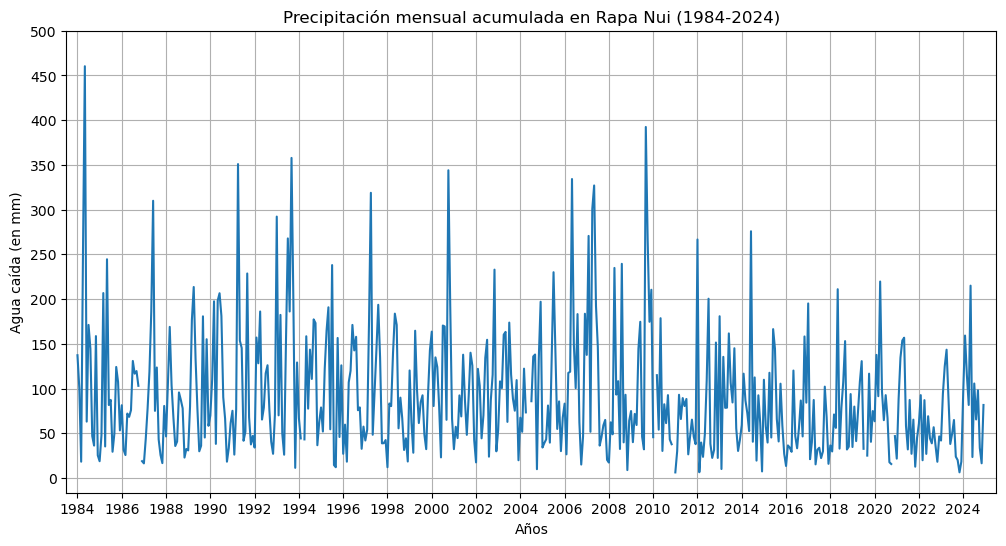

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


datos = pd.read_csv('mataveriPREP9999.dat', delimiter="\t", header=None, na_values=[-9999, -9999.0, "-9999"])

anos = datos.iloc[:,0].to_numpy()
meses = np.tile(np.arange(1, 13), len(anos))
anosconmeses = np.repeat(anos,12)
datosmeses = datos.iloc[:,1:].to_numpy().flatten()
ejex = anosconmeses + (meses - 1)/12

plt.figure(figsize=(12, 6))
plt.plot(ejex, datosmeses)
plt.xlabel("Años")
plt.ylabel("Agua caída (en mm)")
plt.title("Precipitación mensual acumulada en Rapa Nui (1984-2024)")
plt.grid(True)
plt.xlim(anos.min() - 0.5, anos.max() + 1.5)
plt.xticks(np.arange(1984, 2026, 2))
plt.yticks(np.arange(0, 501, 50))
plt.show()

TRADUCCIÓN DEL CÓDIGO

1. Preparación del Entorno
import pandas as pd: Traes la librería experta en manipulación de tablas y bases de datos.

import numpy as np: Traes el motor matemático de Python, que te permite hacer cálculos ultrarrápidos con matrices y vectores (tu reemplazo directo de MATLAB).

import matplotlib.pyplot as plt: Traes la herramienta principal para generar gráficos en 2D.


2. Lectura y Limpieza
datos = pd.read_csv(...): Usas Pandas para abrir el archivo .dat. Con delimiter="\t" le indicas que las columnas están separadas por tabulaciones. Con header=None evitas que se salte la primera fila de datos, y con na_values le ordenas que cualquier -9999 sea destruido y reemplazado por NaN (nulo) inmediatamente al cargar.


3. Transformación del Tiempo (Eje X)
anos = datos.iloc[:,0].to_numpy(): Extraes la primera columna (índice 0) de la tabla y la conviertes en un arreglo matemático puro de NumPy.

meses = np.tile(np.arange(1, 13), len(anos)): Creas un bloque de números del 1 al 12 y lo copias completo, pegándolo uno tras otro tantas veces como años existan en tus datos.

anosconmeses = np.repeat(anos, 12): Tomas tu lista de años y clonas cada elemento 12 veces en su mismo lugar (ej. 1984, 1984, 1984...).

ejex = anosconmeses + (meses - 1)/12: Combinas los dos vectores anteriores con una operación matemática elemento por elemento. Esto convierte tu tiempo discreto (año y mes por separado) en una variable temporal continua y fraccional (ej. enero de 1984 = 1984.0).


4. Desenrrollado de la Variable (Eje Y)
datosmeses = datos.iloc[:, 1:].to_numpy().flatten(): Tomas todas las columnas desde enero (índice 1) hasta diciembre. Al aplicar .flatten(), Python lee esa matriz fila por fila y la aplasta convirtiéndola en un único vector continuo, emparejándose perfectamente con tu ejex.


5. Filtrado
sinnan = ~np.isnan(datosmeses): Creas una "máscara" o filtro booleano (Verdadero/Falso). Le pides a NumPy que identifique dónde NO hay valores nulos. Esto es crucial para que el gráfico no intente dibujar datos vacíos y la línea se mantenga continua.


6. Visualización
plt.figure(figsize=(12, 6)): Defines el tamaño del lienzo en pulgadas (12 de ancho por 6 de alto) antes de empezar a pintar, evitando que la información quede apretada.

plt.plot(ejex[sinnan], datosmeses[sinnan]): Trazas la línea principal del gráfico, aplicándole el filtro sinnan a ambos ejes para usar únicamente los datos válidos.

plt.xlabel(...), plt.ylabel(...), plt.title(...): Asignas los títulos descriptivos para dar contexto científico al gráfico.

plt.grid(True): Activas la cuadrícula de fondo para facilitar la lectura visual de los picos de lluvia.

plt.xlim(...): Ajustas los bordes izquierdo y derecho del gráfico de forma dinámica. Al sumar y restar un pequeño margen al mínimo y máximo de los años, aseguras que los datos nunca toquen el borde del cuadro, sin importar qué base de datos cargues.

plt.xticks(...) y plt.yticks(...): Tomas el control total de las separaciones de la cuadrícula, obligando al Eje X a mostrar marcas cada 2 años y al Eje Y cada 50 mm.

plt.show(): Le indicas al programa que terminaste de configurar todo y que renderice la imagen final en pantalla.